## 1. Dataset Loading and Preprocessing Setup
Initialize dataset directories, load the training and testing sets using `image_dataset_from_directory`, and create an 80-20 training-validation split.

In [ ]:
import os
from pathlib import Path
import pandas as pd
import tensorflow as tf

# 1. Locate project and data directories
project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

data_dir = project_dir / "data"
manifest_path = project_dir / "splits" / "brain_tumor_split_seed123.csv"

# Read the shared CSV manifest
manifest_df = pd.read_csv(manifest_path)

class_names = ["glioma", "meningioma", "notumor", "pituitary"]

train_df = manifest_df[manifest_df["split"] == "train"].copy()
val_df = manifest_df[manifest_df["split"] == "validation"].copy()
test_df = manifest_df[manifest_df["split"] == "test"].copy()

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))
print("Classes:", class_names)


Training images: 4343
Validation images: 1086
Testing images: 1584
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [11]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

tf.keras.utils.set_random_seed(SEED)

def load_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(dataframe, training=False):
    paths = [
        str(data_dir / relative_path)
        for relative_path in dataframe["relative_path"]
    ]
    labels = dataframe["class_id"].to_numpy(dtype="int32")

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [12]:
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_dataset = make_dataset(test_df, training=False)

## 2. Input Pipeline Performance Optimization
Implement TensorFlow `AUTOTUNE`, caching, and prefetching to ensure maximum GPU data throughput during training.


## 3. Baseline Custom CNN Model Architecture
* **Architecture Overview:** 
  * Rescaling layer (normalization to $0-1$)
  * Three Convolutional Blocks with ReLU activation and Max Pooling
  * Flatten and Dense layers with Dropout (0.5) to prevent overfitting
  * Softmax output layer for multi-class classification ($4$ classes)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Performance Optimization (Data traffic to GPU quickly)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 2. creating Custom CNN Model  (Baseline Model)
num_classes = 4

model_1 = models.Sequential([
    # Pixel values (0-255) normalization (0-1)
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Prevent overfitting
    layers.Dense(num_classes, activation='softmax')
])

# Checking the model structure
model_1.summary()

c:\Users\palit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Model Compilation and Training
* **Configuration:** Compiled using the Adam optimizer, Sparse Categorical Crossentropy loss, and evaluated over $10$ epochs.

In [8]:
# Model 1 Compile
model_1.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Training for 10 Epochs
EPOCHS = 10

history_1 = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10


c:\Users\palit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


140/140 ━━━━━━━━━━━━━━━━━━━━ 102s 702ms/step - accuracy: 0.6480 - loss: 0.8628 - val_accuracy: 0.8071 - val_loss: 0.4822
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 682ms/step - accuracy: 0.8087 - loss: 0.4968 - val_accuracy: 0.8527 - val_loss: 0.3806
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 102s 727ms/step - accuracy: 0.8638 - loss: 0.3599 - val_accuracy: 0.8625 - val_loss: 0.3302
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 117s 839ms/step - accuracy: 0.8944 - loss: 0.2762 - val_accuracy: 0.9080 - val_loss: 0.2550
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 114s 812ms/step - accuracy: 0.9259 - loss: 0.1941 - val_accuracy: 0.8973 - val_loss: 0.2894
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 115s 822ms/step - accuracy: 0.9353 - loss: 0.1675 - val_accuracy: 0.9366 - val_loss: 0.2294
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 111s 791ms/step - accuracy: 0.9529 - loss: 0.1356 - val_accuracy: 0.9339 - val_loss: 0.2158
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 113s 809ms/step - accuracy: 0.9670 - loss: 0.092

## 5. Model Evaluation and Performance Metrics
* **Evaluation Suite:** Generates predictions on the test set, prints a classification report (Precision, Recall, F1-Score), plots the Confusion Matrix, and saves the trained baseline model (`baseline_custom_cnn.keras`).

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.75      0.83       386
  meningioma       0.84      0.88      0.86       398
     notumor       0.86      1.00      0.92       400
   pituitary       0.95      0.93      0.94       400

    accuracy                           0.89      1584
   macro avg       0.90      0.89      0.89      1584
weighted avg       0.90      0.89      0.89      1584



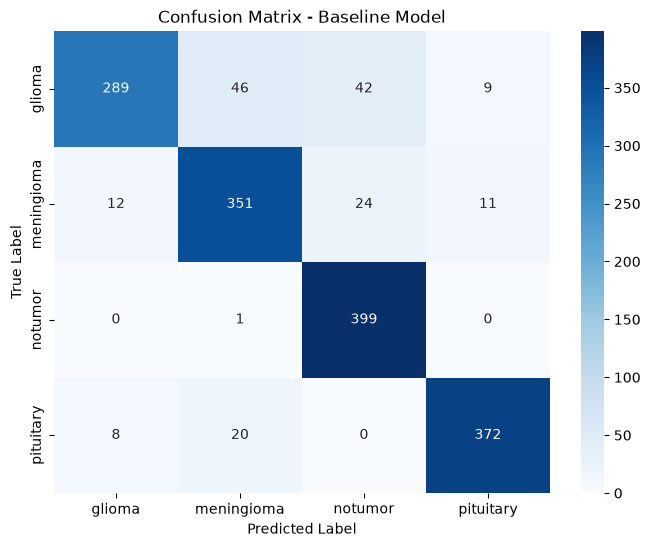

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions on the Test dataset
Y_pred = model_1.predict(test_dataset)
y_pred = np.argmax(Y_pred, axis=1)

# True labels from the Test dataset
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Baseline Model')
plt.show()

## 6.Model Saving


In [10]:

model_1.save('baseline_custom_cnn.keras')